# Tutorial 6

# 1. Linear Regression Recap

The goal of Linear Regression is to find a weight vector $\vec{w}$ such that the product of the feature matrix $X$ and $\vec{w}$ is as close as possible to the true label vector $\vec{y}$.

### Training

-   **Core Formula**: $X_{bias} \cdot \vec{w} = \vec{y}$
-   **Feature Matrix with Bias Term ($X_{bias}$)**: A column of ones is added to the leftmost side of the original feature matrix $X$. This column corresponds to the bias term, $w_0$.
    -   If the original $X$ has dimensions $m \times d$ (m samples, d features), then $X_{bias}$ has dimensions $m \times (d+1)$.
-   **Weight Vector ($\vec{w}$)**: This vector includes the bias term $w_0$ and the weights for the other features, $w_1, ..., w_d$. Its dimension is $(d+1) \times 1$.
    $$
    \vec{w} = \begin{bmatrix} w_0 \\ w_1 \\ \vdots \\ w_d \end{bmatrix}
    $$
-   **Solving for $\vec{w}$**: The solution depends on the system's nature.
    -   **Over-determined System ($m > d+1$)**: Use the left inverse: $\vec{w} = (X^T X)^{-1} X^T \vec{y}$.
    -   **Even-determined System ($m = d+1$)**: Use the direct inverse: $\vec{w} = X^{-1} \vec{y}$.
    -   **Under-determined System ($m < d+1$)**: Use the right inverse: $\vec{w} = X^T (X X^T)^{-1} \vec{y}$.

### Testing

-   **Core Formula**: $\hat{y} = X_{test} \cdot \vec{w}$
-   During the testing phase, the weight vector $\vec{w}$ is known. We multiply the new test data $X_{test}$ (which also needs a bias column) by $\vec{w}$ to get the predicted values $\hat{y}$.

---

## 2. Using Linear Models for Classification

Linear models can be adapted for classification tasks. The core mechanics remain the same; **the only difference is the representation of the target labels, $\vec{y}$**.

### Binary Classification

-   **Labels**: The two classes are represented by discrete values, typically **-1** and **1**.
-   **Training**: The process is identical to linear regression: $X_{bias} \cdot \vec{w} = \vec{y}$. The model learns by treating {-1, 1} as continuous target values.
-   **Testing**:
    1.  **Prediction**: Calculate $\hat{y} = X_{test} \cdot \vec{w}$. The resulting $\hat{y}$ will be a vector of continuous values (e.g., -1.2, 0.8).
    2.  **Decision**: Use the **Sign Function** to convert the continuous predictions into the discrete class labels {-1, 1}.
        $$
        \text{sign}(\hat{y}) = \begin{cases}
        1 & \text{if } \hat{y} \geq 0 \\
        -1 & \text{if } \hat{y} < 0
        \end{cases}
        $$

### Multi-class Classification

-   **Labels**: Use **One-hot Encoding** to represent multiple classes. For $k$ classes, each label $\vec{y_i}$ is a vector of length $k$ with a 1 at the index of the correct class and 0s elsewhere.
    -   Example: For 4 classes, the label '2' becomes `[0, 1, 0, 0]`.
-   **Training**: The training equation is still $X_{bias} \cdot W = Y$. Note that the labels $Y$ and weights $W$ are now matrices.
-   **Testing**:
    1.  **Prediction**: Calculate $\hat{Y} = X_{test} \cdot W$. The output matrix $\hat{Y}$ will contain continuous "score" values. The larger the score, the more confident the model is that a sample belongs to that class.
    2.  **Decision**: Apply the **argmax** function to **each row** of $\hat{Y}$ to find the index of the highest score. This index corresponds to the predicted class, which is then converted back to a one-hot vector.

---

## 3. Handling Non-Linearity: Polynomial Features

When data is not linearly separable (e.g., the XOR problem), a standard linear model will fail.

-   **Core Idea**: Transform the original features into a higher-dimensional space using **basis functions**, making the data linearly separable in the new space. We focus on **Polynomial Basis Functions**.
-   **Feature Transformation**: The original feature matrix $X$ is converted into a polynomial feature matrix $P$. For a 2nd-order polynomial, features $[x_1, x_2]$ would be transformed into $[1, x_1, x_2, x_1^2, x_2^2, x_1x_2]$.
    -   This transformation is handled by library functions and **automatically includes the bias term** (the constant 1).
-   **Training & Testing**: The entire process is identical to linear regression/classification, but $P$ is used instead of $X_{bias}$.
    -   Training: $P \cdot \vec{w} = \vec{y}$
    -   Testing: $\hat{y} = P_{test} \cdot \vec{w}$
-   **Number of Parameters**: For an **n-th order** polynomial model with **r** original features, the number of parameters to learn (i.e., the dimensionality of $\vec{w}$) is given by:
    $$
    C(n+r, r) = \frac{(n+r)!}{n!r!}
    $$
    This is equivalent to the "stars and bars" combinatorics problem of "placing n balls into r distinct boxes."

---

## 4. Ridge Regression (L2 Regularization)

Ridge Regression is an improvement upon standard linear regression.

### Motivation

1.  **A Unified Solution**: Standard linear regression requires different solutions for over-, even-, and under-determined systems because the matrix to be inverted ($X^T X$ or $XX^T$) might be singular (non-invertible). Ridge Regression provides a **single, unified formula that works for all cases**.
2.  **Preventing Overfitting**: Complex models, like high-order polynomials, can fit the training data perfectly but perform poorly on unseen test data. Ridge Regression limits model complexity by penalizing large weight values, thus improving the model's generalization ability.

### Core Formula

-   **Primal Form**:
    $$
    \vec{w} = (X^T X + \lambda I)^{-1} X^T \vec{y}
    $$
    By adding a small positive diagonal matrix $\lambda I$ (where $I$ is the identity matrix) to $X^T X$, the resulting matrix $(X^T X + \lambda I)$ is **guaranteed to be invertible**.
-   **Dual Form**:
    $$
    \vec{w} = X^T (XX^T + \lambda I)^{-1} \vec{y}
    $$
-   The **primal** and **dual** forms are mathematically equivalent. The choice between them is for computational efficiency:
    -   If features $d$ < samples $m$, inverting the $d \times d$ matrix in the primal form is faster.
    -   If samples $m$ < features $d$, inverting the $m \times m$ matrix in the dual form is faster.

### The Regularization Parameter $\lambda$

-   $\lambda$ is a hyperparameter that controls the strength of the regularization.
-   As $\lambda \to 0$, Ridge Regression becomes identical to standard linear regression.
-   As $\lambda \to \infty$, the weights $\vec{w}$ are pushed towards zero, resulting in a very simple model.
-   Increasing $\lambda$ decreases the magnitude of the weights ($||\vec{w}||^2$), leading to a smoother, less overfit model. The loss function becomes:
    $$
    \text{Loss} = \text{MSE} + \lambda ||\vec{w}||_2^2
    $$

### Question 1

Derive the solution for linear ridge regression in dual form.

### Answer:  

For $ \lambda > 0 $,

$$
(X^T X + \lambda I) w = X^T y
$$

$$
\Rightarrow X^T X w + \lambda w = X^T y
$$

$$
\Rightarrow \lambda w = X^T y - X^T X w
$$

$$
\Rightarrow w = \lambda^{-1} (X^T y - X^T X w)
$$

$$
\Rightarrow w = \lambda^{-1} X^T (y - X w)
$$

$$
w = X^T a
$$

where

$$
a = \lambda^{-1} (y - X w)
$$

$$
\Rightarrow \lambda a = (y - X w)
$$

$$
\Rightarrow \lambda a = (y - X X^T a)
$$

$$
\Rightarrow X X^T a + \lambda a = y
$$

$$
\Rightarrow (X X^T + \lambda I) a = y
$$

$$
\Rightarrow a = (X X^T + \lambda I)^{-1} y
$$

Thus,

$$
w = X^T a = X^T (X X^T + \lambda I)^{-1} y.
$$


#### **Why does adding $\lambda I$ ensure that $X^T X + \lambda I$ is invertible?**

##### **Eigenvalues and Positive Definiteness**
- The **invertibility** of a matrix is closely related to its **eigenvalues**.
- A **matrix is invertible** if and only if **all its eigenvalues are nonzero**.
- $ X^T X $ is a **positive semi-definite** matrix, meaning its **eigenvalues are non-negative**:

$$
\text{Eigenvalues of } X^T X \geq 0
$$

- If $ X^T X $ is **singular**, at least **one eigenvalue is zero**, making it **non-invertible**.


##### **Effect of Adding $ \lambda I $**
- Adding $ \lambda I $ **shifts all eigenvalues** of $ X^T X $ by $ \lambda $:

$$
\text{Eigenvalues of } (X^T X + \lambda I) = \text{Eigenvalues of } X^T X + \lambda
$$

- Since $ \lambda > 0 $, **all eigenvalues become strictly positive**:

$$
\text{Eigenvalues of } (X^T X + \lambda I) > 0
$$

- A matrix with **all positive eigenvalues** is **positive definite** and therefore **invertible**.


##### **Why is $ X^T X $ Positive Semi-Definite?**
A matrix $ X^T X $ is **always positive semi-definite** because:

1. For any vector $ v $, the **quadratic form**:

   $$
   v^T (X^T X) v = (X v)^T (X v) = \| X v \|^2
   $$

   is always **non-negative**.

2. Since **squared norms are always non-negative**, we conclude:

   $$
   X^T X \text{ has non-negative eigenvalues.}
   $$

A matrix A is positive semi-definite if and only if all of its eigenvalues $\lambda _i $  satisfy: $\lambda _i \geq 0$.

---

### **Ridge Regression as $L_2$ Regularization**
#### **How does ridge regression relate to $L_2$ regularization?**

##### **Loss Function for Ridge Regression**
Ridge regression minimizes the following loss function:

$$
\text{Loss} = \| y - X w \|^2 + \lambda \| w \|^2
$$

where:
- $\| y - X w \|^2$ is the **mean squared error (MSE)** term.
- $\lambda \| w \|^2$ is the **regularization term**, which **penalizes large weights**.

##### **Why Does $L_2$ Regularization Prevent Overfitting?**
- The term $\lambda \| w \|^2$ **shrinks the weights**, preventing extreme values.
- This helps control **model complexity**, making it **more robust** to noise in the data.
- The **regularization parameter $\lambda$** determines the trade-off:
  - If $\lambda$ is **too small**, the model **overfits** (captures too much noise).
  - If $\lambda$ is **too large**, the model **underfits** (loses important patterns).

##### **Why Does Regularization Make the Model Simpler?**
- Large values in $w$ mean the model relies too much on **specific features**.
- Regularization **smooths out extreme values**, leading to **better generalization**.

---


### Question 2

Given the following data pairs for training:

\begin{split}
\{x = -10\} &\rightarrow \{y = 5\} \\
\{x = -8\} &\rightarrow \{y = 5\} \\
\{x = -3\} &\rightarrow \{y = 4\} \\
\{x = -1\} &\rightarrow \{y = 3\} \\
\{x = 2\} &\rightarrow \{y = 2\} \\
\{x = 8\} &\rightarrow \{y = 2\}
\end{split}

(a) Perform a $3^{rd}$-order polynomial regression and sketch the result of line fitting.  

(b) Given a test point $\{x = 9\}$, predict $y$ using the polynomial model.  

(c) Compare this prediction with that of a linear regression.

### **Answer**
#### **(a) Polynomial Regression**
The polynomial model of 3rd order is:
$$
f(x) = w_0 + w_1 x + w_2 x^2 + w_3 x^3
$$
The matrix $\mathbf{P}$ and target vector $\mathbf{y}$ are:
$$
\mathbf{P} =
\begin{bmatrix}
1 & -10 & 100 & -1000 \\
1 & -8 & 64 & -512 \\
1 & -3 & 9 & -27 \\
1 & -1 & 1 & -1 \\
1 & 2 & 4 & 8 \\
1 & 8 & 64 & 512
\end{bmatrix}, \quad \mathbf{y} =
\begin{bmatrix}
5 \\
5 \\
4 \\
3 \\
2 \\
2
\end{bmatrix}
$$
The solution for $\Phi$ is:
$$
\Phi = (\mathbf{P}^T \mathbf{P})^{-1} \mathbf{P}^T \mathbf{y} =
\begin{bmatrix}
2.6894 \\
-0.3772 \\
0.0134 \\
0.0029
\end{bmatrix}
$$

#### **(b) Prediction for $\{x = 9\}$**
Using the polynomial model:
$$
y_{\text{predict\_Poly}} = 2.4661
$$

#### **(c) Linear Regression**
The linear regression solution is:
$$
\Phi = (X^T X)^{-1} X^T \mathbf{y} =
\begin{bmatrix}
3.1055 \\
-0.1972
\end{bmatrix}
$$
The prediction for $\{x = 9\}$ is:
$$
y_{\text{predict\_Linear}} = 1.3303
$$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from sklearn.preprocessing import PolynomialFeatures

# Training Data
X_train = np.array([-10, -8, -3, -1, 2, 8]).reshape(-1, 1)
y_train = np.array([5, 5, 4, 3, 2, 2]).reshape(-1, 1)

# Test Data Point
X_test = np.array([[9]])

# Create Polynomial Features (3rd Order)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X_train)

# Compute w using normal equation for polynomial regression
w_poly = inv(X_poly.T @ X_poly) @ X_poly.T @ y_train

# Predict for test point x = 9
X_test_poly = poly.transform(X_test)
y_pred_poly = X_test_poly @ w_poly

# Add Bias Term for Linear Regression
X_lin = np.hstack((np.ones_like(X_train), X_train))

# Compute w using normal equation for linear regression
w_lin = inv(X_lin.T @ X_lin) @ X_lin.T @ y_train

# Predict for test point x = 9 using linear regression
X_test_lin = np.array([[1, 9]])
y_pred_lin = X_test_lin @ w_lin


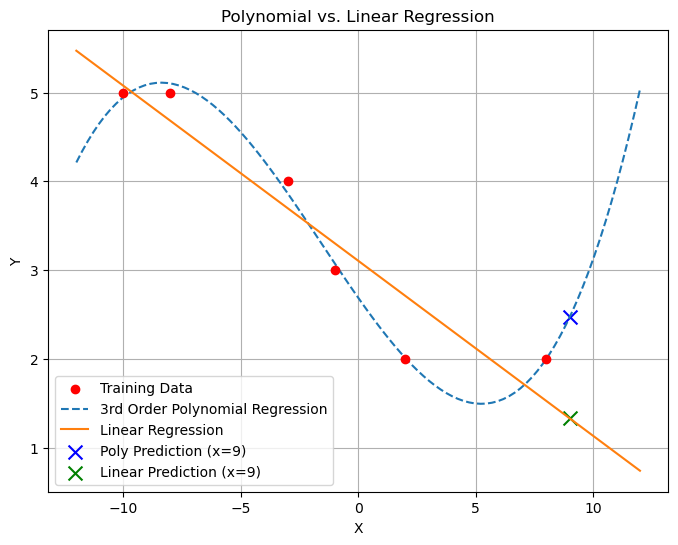

In [2]:
# Generate points for smooth curve
x_range = np.linspace(-12, 12, 100).reshape(-1, 1)
X_range_poly = poly.transform(x_range)
y_range_poly = X_range_poly @ w_poly

X_range_lin = np.hstack((np.ones_like(x_range), x_range))
y_range_lin = X_range_lin @ w_lin

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='red', label="Training Data", zorder=3)
plt.plot(x_range, y_range_poly, label="3rd Order Polynomial Regression", linestyle="--")
plt.plot(x_range, y_range_lin, label="Linear Regression", linestyle="-")
plt.scatter(X_test, y_pred_poly, color="blue", marker="x", s=100, label="Poly Prediction (x=9)")
plt.scatter(X_test, y_pred_lin, color="green", marker="x", s=100, label="Linear Prediction (x=9)")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial vs. Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.array([[1, 2, 3]])

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(input_features=['x0', 'x1', 'x2'])
print(feature_names)

['1' 'x0' 'x1' 'x2' 'x0^2' 'x0 x1' 'x0 x2' 'x1^2' 'x1 x2' 'x2^2']


### Question 3

(a) Write down the expression for a $3^{rd}$-order polynomial model having a 3-dimensional input.  

(b) Write down the $\mathbf{P}$ matrix for this polynomial given $X = \begin{bmatrix} 1 & 0 & 1 \\ 1 & -1 & 1 \end{bmatrix}$.  

(c) Given $y = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$, can a unique solution be obtained in dual form? If so, proceed to solve it.  

(d) Given $y = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$, can the primal ridge regression be applied to obtain a unique solution? If so, proceed to solve it.

### **Answer**
#### **(a) Polynomial Model**
The polynomial model of **3rd order** for a **3-dimensional input** is:


$$
\begin{aligned}
f(x) =\, & w_0 + w_1 x_1 + w_2 x_2 + w_3 x_3 \\
&+ w_{11} x_1^2 + w_{22} x_2^2 + w_{33} x_3^2 \\
&+ w_{12} x_1 x_2 + w_{13} x_1 x_3 + w_{23} x_2 x_3 \\
&+ w_{111} x_1^3 + w_{222} x_2^3 + w_{333} x_3^3 \\
&+ w_{112} x_1^2 x_2 + w_{113} x_1^2 x_3 + w_{122} x_1 x_2^2 \\
&+ w_{223} x_2^2 x_3 + w_{133} x_1 x_3^2 + w_{233} x_2 x_3^2 \\
&+ w_{123} x_1 x_2 x_3.
\end{aligned}
$$


---

#### **(b) Constructing the Matrix $ \mathbf{P} $**
For input matrix:

$$
X =
\begin{bmatrix}
1 & 0 & 1 \\
1 & -1 & 1
\end{bmatrix}
$$

The corresponding **design matrix** $ \mathbf{P} $ is:

$$
\mathbf{P} =
\begin{bmatrix}
1 & 1 & 0 & 1 & 0 & 0 & 1 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 1 & 0 & 0 & 1 & 0 & 1 \\
1 & 1 & -1 & 1 & -1 & -1 & 1 & 1 & 1 & 1 & -1 & 1 & 1 & 1 & 1 & -1 & -1 & 1 & -1 & 1
\end{bmatrix}
$$

---

#### **(c) Dual Form Solution**
The **dual form** solution is:

$$
w = P^T (P P^T)^{-1} y
$$

Computing the inverse:

$$
(P P^T)^{-1} =
\begin{bmatrix}
10 & 10 \\
10 & 20
\end{bmatrix}^{-1}
$$

Then solving for $ w $

---

#### **(d) Primal Ridge Regression Solution**
The **primal ridge regression** solution is:

$$
w = (P^T P + \lambda I)^{-1} P^T y
$$

where $ \lambda > 0 $.

In [4]:
import numpy as np
from numpy.linalg import inv
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1,0,1], [1,-1,1]])
y = np.array([0, 1])

## Generate polynomial features
order = 3
poly = PolynomialFeatures(order)
P = poly.fit_transform(X)

# dual solution (without ridge)
w_dual = P.T @ inv(P @ P.T) @ y
print(w_dual)

# primal ridge
reg_L = 0.0001*np.identity(P.shape[1])
w_primal_ridge = inv(P.T @ P + reg_L) @ P.T @ y
print(w_primal_ridge)

[ 0.   0.  -0.1  0.   0.  -0.1  0.   0.1 -0.1  0.   0.  -0.1  0.   0.1
 -0.1  0.  -0.1  0.1 -0.1  0. ]
[ 9.99976692e-07  9.99972144e-07 -9.99980001e-02  9.99971235e-07
  9.99967597e-07 -9.99980000e-02  9.99966687e-07  9.99980001e-02
 -9.99980001e-02  9.99973054e-07  9.99965778e-07 -9.99980000e-02
  9.99966687e-07  9.99980001e-02 -9.99980001e-02  9.99971235e-07
 -9.99980001e-02  9.99980000e-02 -9.99980000e-02  9.99970325e-07]


#### Why Can We Use Both Forms?

Even though we usually switch between dual and primal forms based on matrix dimensions, in Q3, both forms give unique solutions due to regularization $\lambda I$.  

**Both Solutions Are Mathematically Equivalent.**

For any ridge regression problem, we can derive:

$$
(P^T P + \lambda I)^{-1} P^T y = P^T (P P^T + \lambda I)^{-1} y.
$$

This means that both approaches compute the same weight vector $w$.

### Question 4

Given the training data:
\begin{split}
\{x = -1\} \rightarrow \{y = \text{class1}\} \\
\{x = 0\} \rightarrow \{y = \text{class1}\} \\
\{x = 0.5\} \rightarrow \{y = \text{class2}\} \\
\{x = 0.3\} \rightarrow \{y = \text{class1}\} \\
\{x = 0.8\} \rightarrow \{y = \text{class2}\}
\end{split}


Predict the class label for $\{x = -0.1\}$ and $\{x = 0.4\}$ using linear regression with signum discrimination.

In [5]:
import numpy as np
from numpy.linalg import inv
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1,-1], [1,0], [1,0.5], [1,0.3], [1,0.8]])
y = np.array([1, 1, -1, 1, -1])

# Linear regression for classification
w = inv(X.T @ X) @ X.T @ y
print(w)

Xt = np.array([[1,-0.1], [1,0.4]])
y_predict = Xt @ w
print(y_predict)

y_class_predict = np.sign(y_predict)
print(y_class_predict)

[ 0.33333333 -1.11111111]
[ 0.44444444 -0.11111111]
[ 1. -1.]


### Question 5

Given the training data:
\begin{split}
\{x = -1\} \rightarrow \{y = \text{class1}\} \\
\{x = 0\} \rightarrow \{y = \text{class1}\} \\
\{x = 0.5\} \rightarrow \{y = \text{class2}\} \\
\{x = 0.3\} \rightarrow \{y = \text{class3}\} \\
\{x = 0.8\} \rightarrow \{y = \text{class2}\}
\end{split}


(a) Predict the class label for $\{x = -0.1\}$ and $\{x = 0.4\}$ based on linear regression towards a one-hot encoded target.  

(b) Predict the class label for $\{x = -0.1\}$ and $\{x = 0.4\}$ using a polynomial model of 5th order and a one-hot encoded target.

In [6]:
import numpy as np
from numpy.linalg import inv
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1,-1], [1,0], [1,0.5], [1,0.3], [1,0.8]])
Y = np.array([[1,0,0], [1,0,0], [0,1,0], [0,0,1], [0,1,0]])

print("(a)")

# Linear regression for classification
W = inv(X.T @ X) @ X.T @ Y
print(W)

Xt = np.array([[1,-0.1], [1,0.4]])
y_predict = Xt @ W
print(y_predict)

y_class_predict = [[1 if y == max(x) else 0 for y in x] for x in y_predict ] 
print(y_class_predict)

print("(b)")

# Polynomial regression for 
# Generate polynomial features
order = 5
poly = PolynomialFeatures(order)
# only the data column (2nd) is needed for generation of polynomial terms
# X_raw
reshaped = X[:,1].reshape(len(X[:,1]),1)
P = poly.fit_transform(reshaped)
reshaped = Xt[:,1].reshape(len(Xt[:,1]),1)
Pt = poly.fit_transform(reshaped)
# dual solution (without ridge)
Wp_dual = P.T @ inv(P @ P.T) @ Y
print(Wp_dual)
yp_predict = Pt @ Wp_dual
print(yp_predict)
yp_class_predict = [[1 if y == max(x) else 0 for y in x] for x in yp_predict ] 
print(yp_class_predict)

(a)
[[ 0.47798742  0.33333333  0.18867925]
 [-0.64989518  0.55555556  0.09433962]]
[[0.54297694 0.27777778 0.17924528]
 [0.21802935 0.55555556 0.22641509]]
[[1, 0, 0], [0, 1, 0]]
(b)
[[ 1.00000000e+00  1.06581410e-14 -5.68434189e-14]
 [-5.30313768e+00 -3.70234958e+00  9.00548727e+00]
 [ 5.21976232e+00  1.08728407e+01 -1.60926030e+01]
 [ 6.66624941e+00  9.46978846e+00 -1.61360379e+01]
 [-6.47651463e+00 -1.29098961e+01  1.93864107e+01]
 [-2.61986403e+00 -7.80449422e+00  1.04243583e+01]]
[[ 1.57522369  0.46828063 -1.04350432]
 [-0.05207932  0.45436978  0.59770954]]
[[1, 0, 0], [0, 0, 1]]


### Question 6

Get the data set “`from sklearn.datasets import load_iris`”. Use Python to perform the following tasks.

(a) Split the database into two sets: 74% of samples for training, and 26% of samples for testing. Hint: you might want to utilize `from sklearn.model_selection import train_test_split` for the splitting.  

(b) Construct the target output using one-hot encoding.  

(c) Perform a linear regression for classification (without inclusion of ridge, utilizing one-hot encoding for the learning target) and compute the number of test samples that are classified correctly.  

(d) Using the same training and test sets as in above, perform a 2nd-order polynomial regression for classification (again, without inclusion of ridge, utilizing one-hot encoding for the learning target) and compute the number of test samples that are classified correctly. Hint: you might want to use `from sklearn.preprocessing import PolynomialFeatures` for generation of the polynomial matrix.

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
import numpy as np
from numpy.linalg import inv

# Load Iris dataset
iris_dataset = load_iris()
X = iris_dataset['data']
y = iris_dataset['target']

# (a) Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.26, random_state=0)


bias = np.ones((X_train.shape[0], 1))
X_train_b = np.concatenate((bias, X_train), axis = 1)
bias = np.ones((X_test.shape[0], 1))
X_test_b = np.concatenate((bias, X_test), axis = 1)


# (b) One-hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False)
reshaped = y_train.reshape(len(y_train), 1)
Ytr_onehot = onehot_encoder.fit_transform(reshaped)
reshaped = y_test.reshape(len(y_test), 1)
Yts_onehot = onehot_encoder.fit_transform(reshaped)

# (c) Linear Classification
w = inv(X_train_b.T @ X_train_b) @ X_train_b.T @ Ytr_onehot
yt_est = X_test_b @ w
yt_cls = [[1 if y == max(x) else 0 for y in x] for x in yt_est]
# print(yt_cls)
difference = np.abs(np.matrix(Yts_onehot) - np.matrix(yt_cls))
# print(difference)
correct = np.where(~difference.any(axis=1))[0]
accuracy = len(correct) / len(difference)
print(f" {len(correct)} / {len(difference)}")
print("Linear regression accuracy:", accuracy)

# (d) Polynomial Classification
poly = PolynomialFeatures(2)
P = poly.fit_transform(X_train)
Pt = poly.fit_transform(X_test)

if P.shape[0] > P.shape[1]:
    wp = inv(P.T @ P) @ P.T @ Ytr_onehot
else:
    wp = P.T @ inv(P @ P.T) @ Ytr_onehot

yt_est_p = Pt @ wp
yt_cls_p = [[1 if y == max(x) else 0 for y in x] for x in yt_est_p]
difference_p = np.abs(np.matrix(Yts_onehot) - np.matrix(yt_cls_p))
correct_p = np.where(~difference_p.any(axis=1))[0]
accuracy_p = len(correct_p) / len(difference_p)
print(f" {len(correct_p)} / {len(difference_p)}")
print("Polynomial regression accuracy:", accuracy_p)

 30 / 39
Linear regression accuracy: 0.7692307692307693
 38 / 39
Polynomial regression accuracy: 0.9743589743589743


### Question 7

**MCQ**: There could be more than one answer. Given three samples of two-dimensional data points:
$$
X = \begin{bmatrix} 1 & 1 \\ 0 & 1 \\ 3 & 3 \end{bmatrix}
$$
with corresponding target vector:
$$
y = \begin{bmatrix} 1 \\ 0 \\ 1 \end{bmatrix}
$$
Suppose you want to use a full third-order polynomial model to fit these data. Which of the following is/are true?

a) The polynomial model has 10 parameters to learn.  

b) The polynomial learning system is an under-determined one.  

c) The learning of the polynomial model has an infinite number of solutions.  

d) The input matrix $ X $ has linearly dependent samples.  

e) None of the above.

**Answer**: a, b, c, d  

##### **Option a**: The polynomial model has 10 parameters to learn.
- **True**. A full third-order polynomial model for 2D input data includes the following terms:
  - $1$ (constant term)
  - $x_1$, $x_2$ (linear terms)
  - $x_1^2$, $x_1 x_2$, $x_2^2$ (quadratic terms)
  - $x_1^3$, $x_1^2 x_2$, $x_1 x_2^2$, $x_2^3$ (cubic terms)
  - Total: **10 parameters**.

##### **Option b**: The polynomial learning system is an under-determined one.
- **True**. The system is under-determined because:
  - Number of samples (3) < Number of parameters (10).
  - There are infinitely many solutions that can fit the data.

##### **Option c**: The learning of the polynomial model has an infinite number of solutions.
- **True**. Since the system is under-determined (more parameters than samples), there are infinitely many solutions that satisfy the equations.

##### **Option d**: The input matrix $ X $ has linearly dependent samples.
- **True**. The third row of $ X $ is a linear combination of the first two rows:
  - Row 3 = 3 * Row 1 + 0 * Row 2.
  - This makes the rows linearly dependent.

##### **Option e**: None of the above.
- **False**. Options a, b, c, and d are all true.

### Question 8

**MCQ**: There could be more than one answer. Which of the following is/are true?

a) The polynomial model can be used to solve problems with nonlinear decision boundaries.  

b) The ridge regression cannot be applied to multi-target regression.  

c) The solution for learning feature $ X $ with target $ y $ based on linear ridge regression can be written as $ \hat{\mathbf{w}} = (X^T X + \lambda I)^{-1} X^T y $ for $ \lambda > 0 $. As $ \lambda $ increases, $ \hat{\mathbf{w}}^T \hat{\mathbf{w}} $ decreases.  

d) If there are four data samples with two input features each, the full second-order polynomial model is an over-determined system.

**Answer**: a, c  

##### **Option a**: The polynomial model can be used to solve problems with nonlinear decision boundaries.
- **True**. Polynomial models can capture nonlinear relationships in the data by introducing higher-order terms (e.g., $x^2$, $x^3$, $x_1 x_2$).

##### **Option b**: The ridge regression cannot be applied to multi-target regression.
- **False**. Ridge regression can be applied to multi-target regression. The regularization term $\lambda I$ is added to the normal equations, and the solution can be extended to multiple targets.

##### **Option c**: The solution for learning feature $ X $ with target $ y $ based on linear ridge regression can be written as $ \hat{\mathbf{w}} = (X^T X + \lambda I)^{-1} X^T y $ for $ \lambda > 0 $. As $ \lambda $ increases, $ \hat{\mathbf{w}}^T \hat{\mathbf{w}} $ decreases.
- **True**. The ridge regression solution is:
  $$
  \hat{\mathbf{w}} = (X^T X + \lambda I)^{-1} X^T y
  $$
  As $\lambda$ increases, the regularization term $\lambda I$ penalizes large weights, causing $ \hat{\mathbf{w}}^T \hat{\mathbf{w}} $ (the squared norm of the weights) to decrease.

##### **Option d**: If there are four data samples with two input features each, the full second-order polynomial model is an over-determined system.
- **False**. A full second-order polynomial model for 2D input data includes the following terms:
  - $1$ (constant term)
  - $x_1$, $x_2$ (linear terms)
  - $x_1^2$, $x_1 x_2$, $x_2^2$ (quadratic terms)
  - Total: **6 parameters**.
  - With 4 samples, the system is **under-determined** (4 equations < 6 parameters).